# Zomato Operations - EDA

Project - Zomato Delivery Operations Analytics

Author: Rishav Raj

Dataset: https://www.kaggle.com/datasets/saurabhbadole/zomato-delivery-operations-analytics-dataset

Just exploring what affects delivery time here - weather, traffic, city, vehicle, rating, etc.

Note: no "zone" column in this data so using City instead, and no "Rainy" weather label so using "Stormy" as the closest thing to rain.

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/Zomato_Dataset.csv', na_values=['NaN'])
df.shape

(45584, 20)

In [93]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [94]:
df.rename(columns={
    'ID': 'id',
    'Delivery_person_ID': 'delivery_person_id',
    'Delivery_person_Age': 'age',
    'Delivery_person_Ratings': 'rating',
    'Order_Date': 'order_date',
    'Time_Orderd': 'time_orderd',
    'Weather_conditions': 'weather',
    'Road_traffic_density': 'traffic',
    'Type_of_order': 'order_type',
    'Type_of_vehicle': 'vehicle',
    'multiple_deliveries': 'multiple_deliveries',
    'Festival': 'festival',
    'City': 'city',
    'Time_taken (min)': 'time_taken'
}, inplace=True)

df = df[['id', 'delivery_person_id', 'age', 'rating', 'order_date', 'time_orderd',
         'weather', 'traffic', 'order_type', 'vehicle', 'multiple_deliveries',
         'festival', 'city', 'time_taken']]
df.head()

,id,delivery_person_id,age,rating,order_date,time_orderd,weather,traffic,order_type,vehicle,multiple_deliveries,festival,city,time_taken
0,0xcdcd,DEHRES17DEL01,36.0,4.2,12-02-2022,21:55,Fog,Jam,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,13-02-2022,14:55,Stormy,High,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,04-03-2022,17:30,Sandstorms,Medium,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,13-02-2022,09:20,Sandstorms,Low,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,14-02-2022,19:50,Fog,Jam,Snack,scooter,1.0,No,Metropolitian,41


## 1.Cleaning

`na_values=['NaN']` in read_csv already caught the missing values, so no separate NaN cleanup step needed. Just stripping whitespace off the text columns and fixing the date/time columns.

In [95]:
text_cols = ['weather', 'traffic', 'order_type', 'vehicle', 'festival', 'city']
df[text_cols] = df[text_cols].apply(lambda col: col.str.strip())
df.isna().sum()

id                        0
delivery_person_id        0
age                    1854
rating                 1908
order_date                0
time_orderd            1731
weather                 616
traffic                 601
order_type                0
vehicle                   0
multiple_deliveries     993
festival                228
city                   1200
time_taken                0
dtype: int64

In [96]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')
df['order_month'] = df['order_date'].dt.to_period('M').astype(str)
df['is_weekend'] = df['order_date'].dt.dayofweek >= 5
df['order_hour'] = pd.to_datetime(df['time_orderd'], format='%H:%M', errors='coerce').dt.hour
df.head()

,id,delivery_person_id,age,rating,order_date,time_orderd,weather,traffic,order_type,vehicle,multiple_deliveries,festival,city,time_taken,order_month,is_weekend,order_hour
0,0xcdcd,DEHRES17DEL01,36.0,4.2,2022-02-12,21:55,Fog,Jam,Snack,motorcycle,3.0,No,Metropolitian,46,2022-02,True,21.0
1,0xd987,KOCRES16DEL01,21.0,4.7,2022-02-13,14:55,Stormy,High,Meal,motorcycle,1.0,No,Metropolitian,23,2022-02,True,14.0
2,0x2784,PUNERES13DEL03,23.0,4.7,2022-03-04,17:30,Sandstorms,Medium,Drinks,scooter,1.0,No,Metropolitian,21,2022-03,False,17.0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,2022-02-13,09:20,Sandstorms,Low,Buffet,motorcycle,0.0,No,Metropolitian,20,2022-02,True,9.0
4,0xdb64,KNPRES14DEL02,24.0,4.7,2022-02-14,19:50,Fog,Jam,Snack,scooter,1.0,No,Metropolitian,41,2022-02,False,19.0


In [97]:
df.describe()

,age,rating,order_date,multiple_deliveries,time_taken,order_hour
count,43730.000000,43676.000000,45584,44591.000000,45584.000000,39785.000000
mean,29.566911,4.633774,2022-03-13 16:31:17.711477,0.744635,26.293963,17.575267
min,15.000000,1.000000,2022-02-11 00:00:00,0.000000,10.000000,8.000000
25%,25.000000,4.500000,2022-03-04 00:00:00,0.000000,19.000000,15.000000
50%,30.000000,4.700000,2022-03-15 00:00:00,1.000000,26.000000,19.000000
75%,35.000000,4.900000,2022-03-27 00:00:00,1.000000,32.000000,21.000000
max,50.000000,6.000000,2022-04-06 00:00:00,3.000000,54.000000,23.000000
std,5.815064,0.334744,NaN,0.572510,9.384298,4.525352


## 2.Delivery time overall

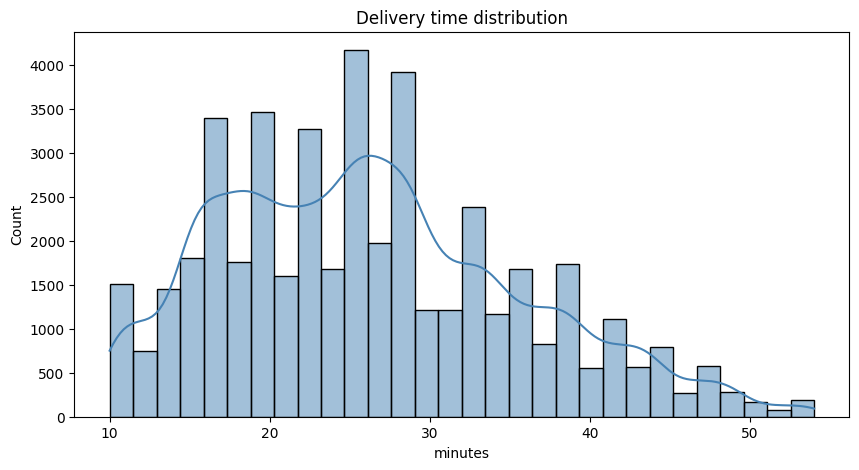

In [98]:
plt.figure(figsize=(10, 5))
sns.histplot(df['time_taken'], bins=30, kde=True, color='steelblue')
plt.title('Delivery time distribution')
plt.xlabel('minutes')
plt.show()

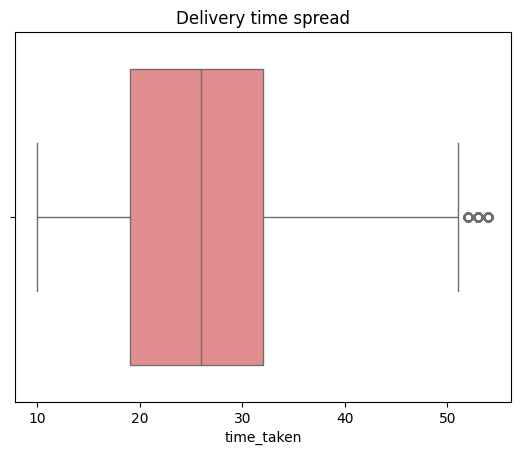

mean: 26.29
median: 26.0


In [14]:
sns.boxplot(x=df['time_taken'], color='lightcoral')
plt.title('Delivery time spread')
plt.show()

print('mean:', round(df['time_taken'].mean(), 2))
print('median:', df['time_taken'].median())

## 3.Monthly trend

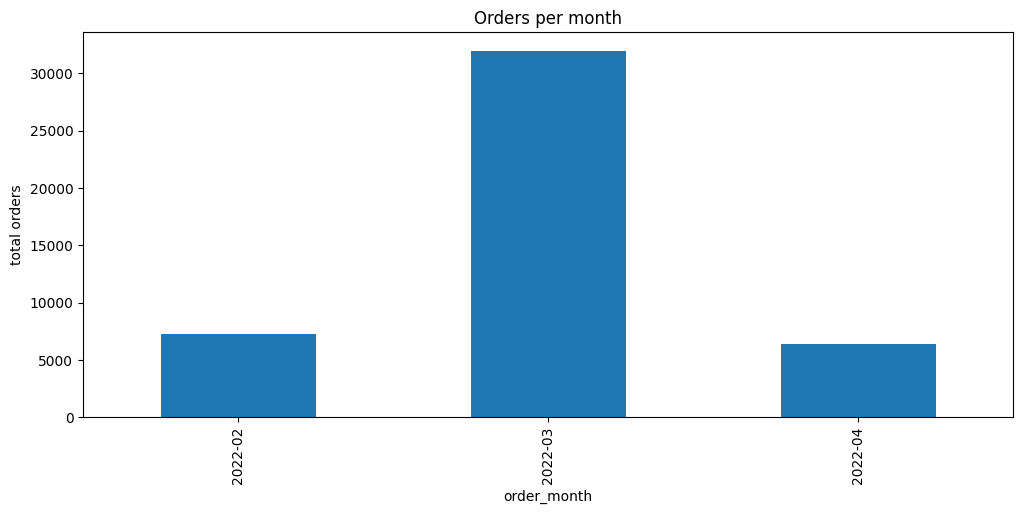

In [70]:
plt.figure(figsize=(12, 5))
df.groupby('order_month')['id'].count().plot(kind='bar', title='Orders per month')
plt.ylabel('total orders')
plt.show()

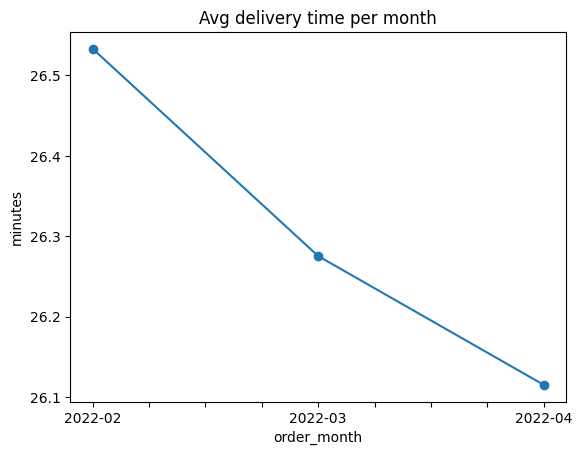

In [10]:
df.groupby('order_month')['time_taken'].mean().plot(kind='line', marker='o', title='Avg delivery time per month')
plt.ylabel('minutes')
plt.show()

## 4.Weekday vs weekend

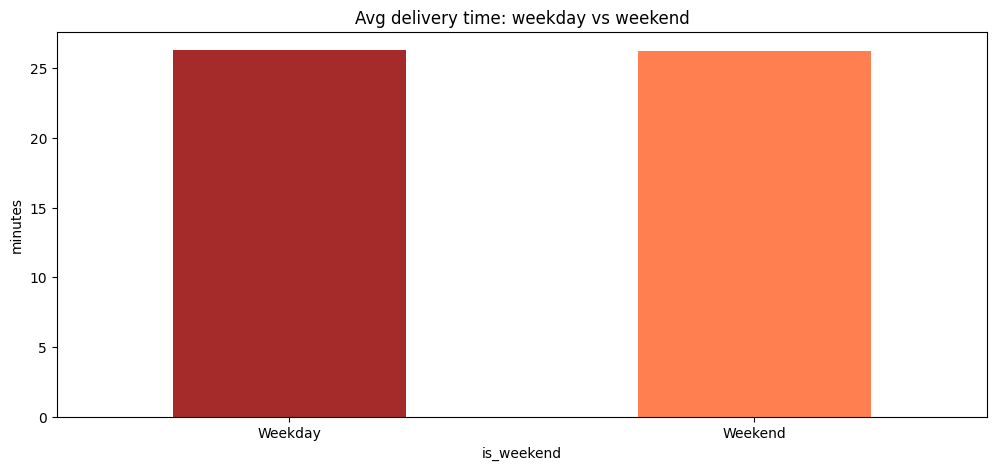

In [69]:
plt.figure(figsize=(12, 5))
df.groupby('is_weekend')['time_taken'].mean().rename({True: 'Weekend', False: 'Weekday'}).plot(
    kind='bar', title='Avg delivery time: weekday vs weekend', color=['brown','coral'])
plt.ylabel('minutes')
plt.xticks(rotation=0)
plt.show()

## 5.Peak order hours

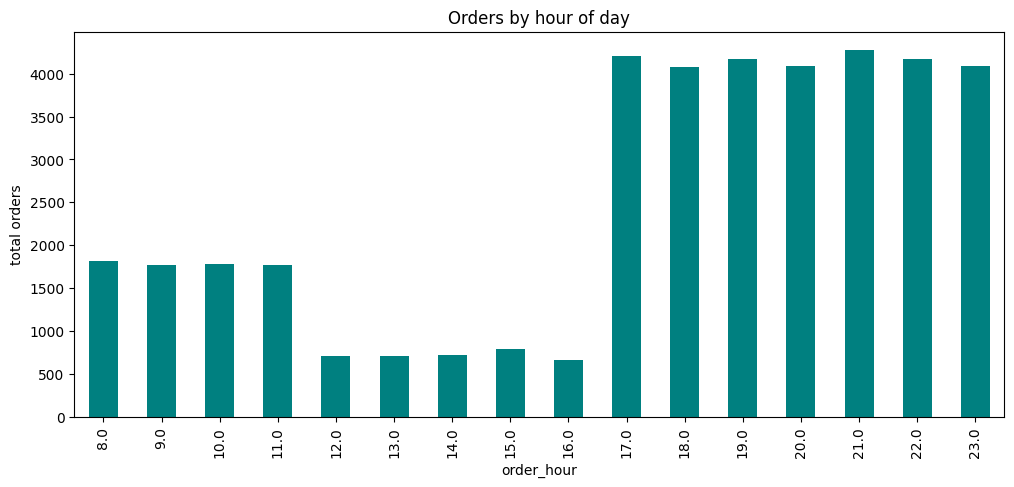

In [68]:
plt.figure(figsize=(12, 5))
df.groupby('order_hour')['id'].count().plot(kind='bar', title='Orders by hour of day', color = 'teal')
plt.ylabel('total orders')
plt.show()

## 6.City breakdown

No zone column, using City as the closest thing to it.

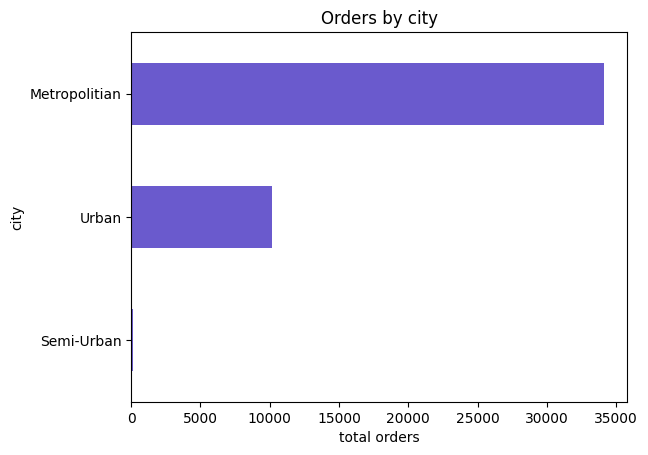

In [41]:

df.groupby('city')['id'].count().sort_values().plot(kind='barh', title='Orders by city', color='slateblue')
plt.xlabel('total orders')
plt.show()

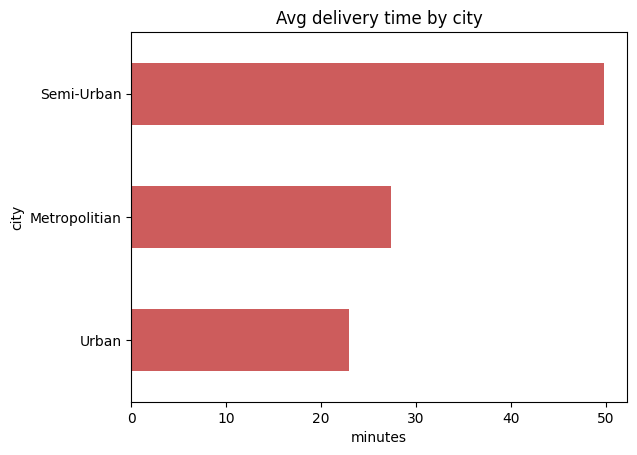

In [35]:
df.groupby('city')['time_taken'].mean().sort_values().plot(kind='barh', title='Avg delivery time by city', color='indianred')
plt.xlabel('minutes')
plt.show()

## 7.Weather

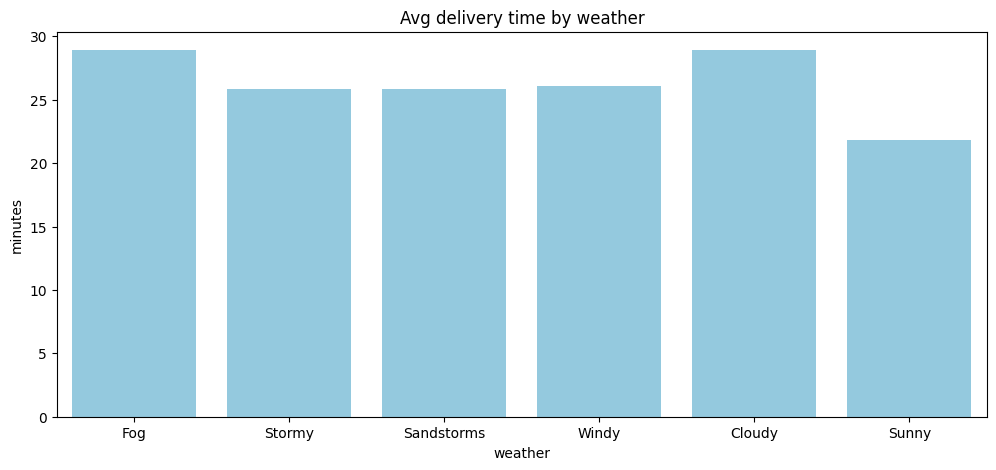

In [67]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='weather', y='time_taken', errorbar=None, color='skyblue')
plt.title('Avg delivery time by weather')
plt.ylabel('minutes')
plt.show()

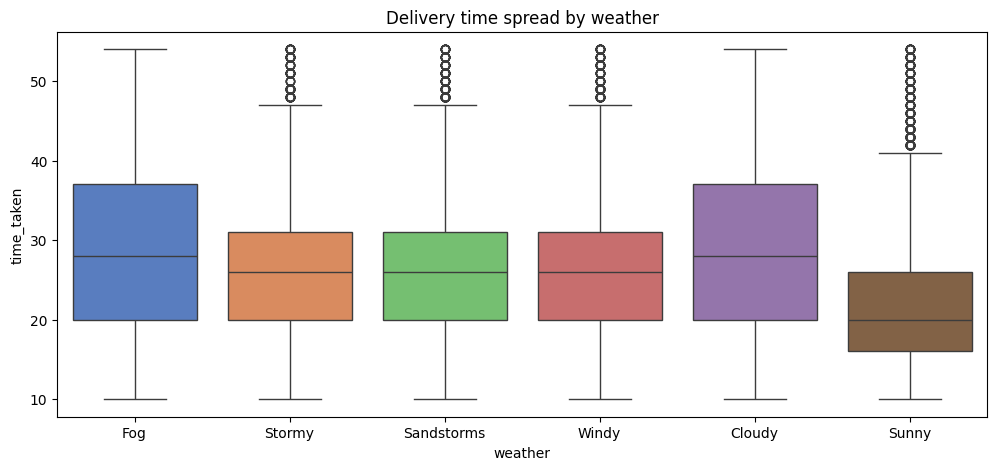

In [65]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='weather', y='time_taken',palette='muted', hue = 'weather', legend = False)
plt.title('Delivery time spread by weather')
plt.show()

## 8.Traffic

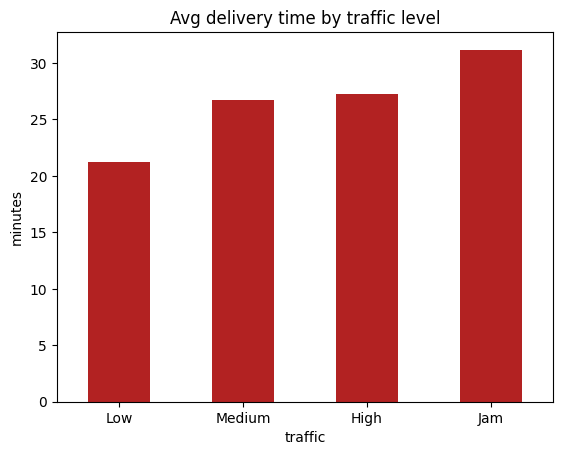

In [48]:
traffic_order = ['Low', 'Medium', 'High', 'Jam']
df.groupby('traffic')['time_taken'].mean().reindex(traffic_order).plot(
    kind='bar', title='Avg delivery time by traffic level', color='firebrick')
plt.ylabel('minutes')
plt.xticks(rotation=0)
plt.show()

## 9.Weather + traffic together

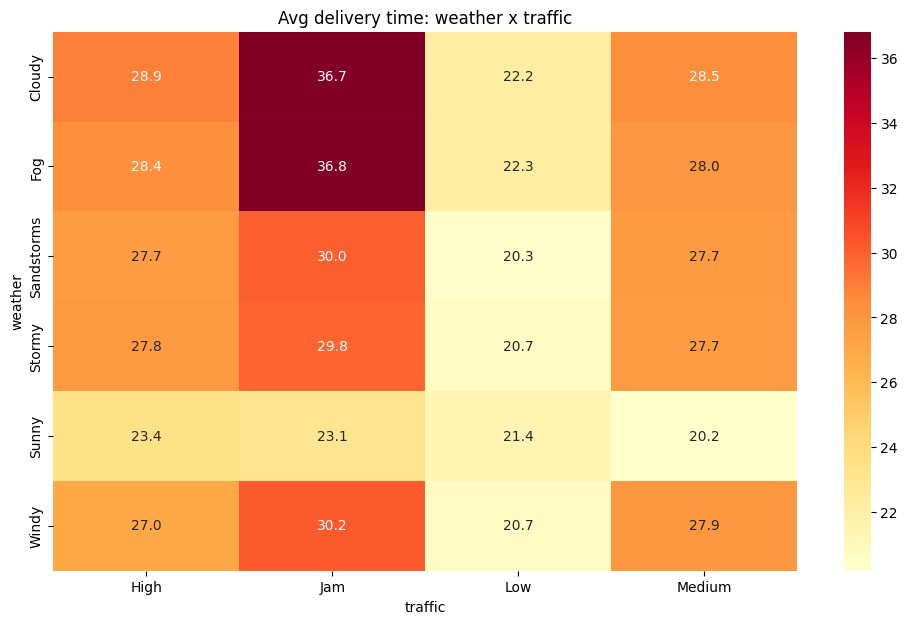

In [64]:
plt.figure(figsize=(12, 7))
pivot = df.pivot_table(index='weather', columns='traffic', values='time_taken', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Avg delivery time: weather x traffic')
plt.show()

## 10.Vehicle type

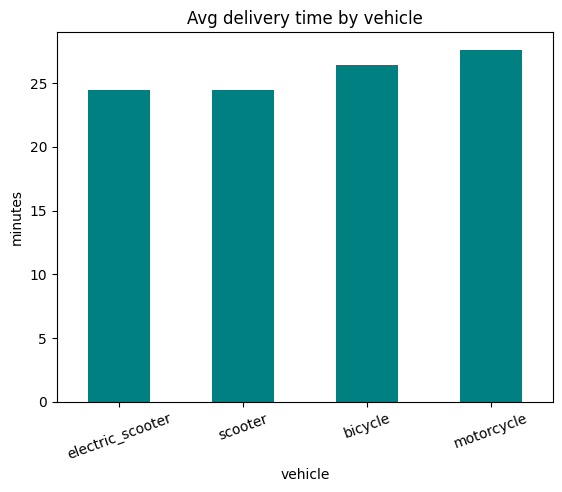

In [50]:
df.groupby('vehicle')['time_taken'].mean().sort_values().plot(kind='bar', title='Avg delivery time by vehicle', color='teal')
plt.ylabel('minutes')
plt.xticks(rotation=20)
plt.show()

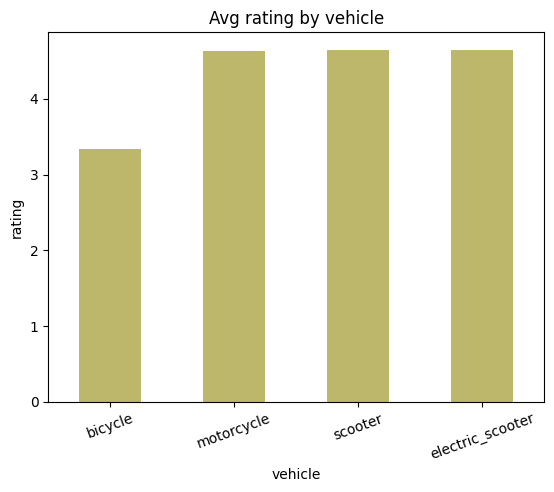

In [51]:
df.groupby('vehicle')['rating'].mean().sort_values().plot(kind='bar', title='Avg rating by vehicle', color = 'darkkhaki')
plt.ylabel('rating')
plt.xticks(rotation=20)
plt.show()

## 11.Order type

Snack / Meal / Drinks / Buffet, no grocery category in this data.

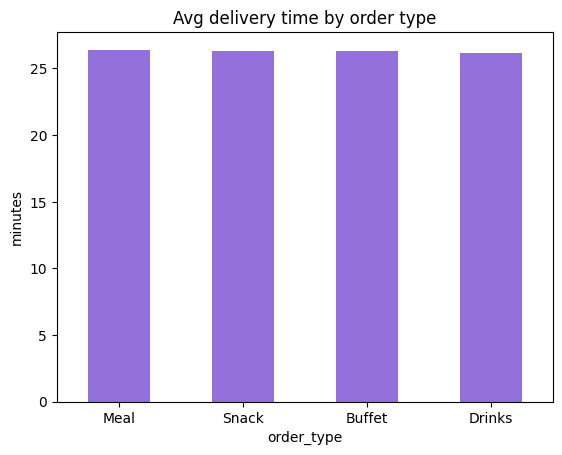

In [55]:
df.groupby('order_type')['time_taken'].mean().sort_values(ascending=False).plot(
    kind='bar', title='Avg delivery time by order type', color='mediumpurple')
plt.ylabel('minutes')
plt.xticks(rotation=0)
plt.show()

## 12.Rating vs delivery time

Bucketing ratings to see if a higher rated driver is actually delivering faster.

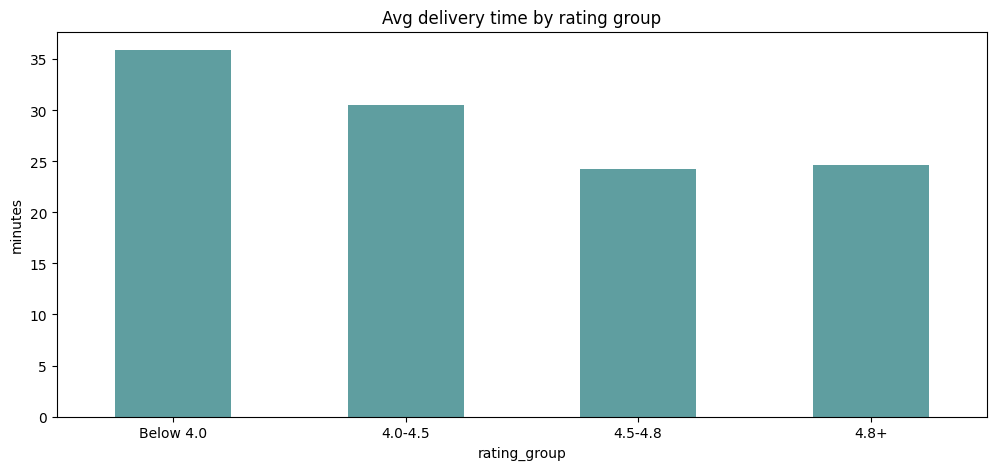

In [90]:
plt.figure(figsize=(12, 5))
df['rating_group'] = pd.cut(df['rating'], bins=[0, 4.0, 4.5, 4.8, 5.0],
                              labels=['Below 4.0', '4.0-4.5', '4.5-4.8', '4.8+'])

df.groupby('rating_group', observed=True)['time_taken'].mean().plot(
    kind='bar', title='Avg delivery time by rating group', color='cadetblue')
plt.ylabel('minutes')
plt.xticks(rotation=0)
plt.show()

## 13.Driver age vs delivery time

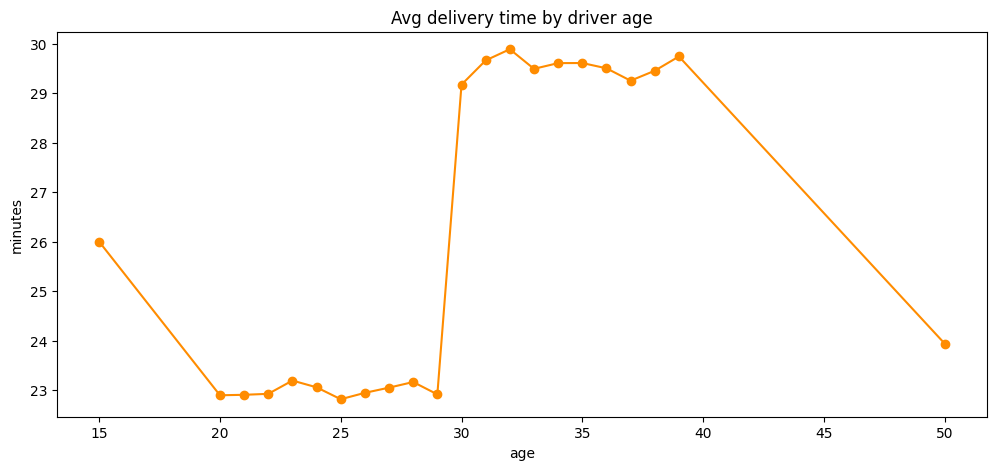

In [60]:
plt.figure(figsize=(12, 5))
df.groupby('age')['time_taken'].mean().plot(kind='line', marker='o', title='Avg delivery time by driver age', color='darkorange')
plt.ylabel('minutes')
plt.show()

No clear pattern here, avg time doesn't really go up or down as age increases.

## 14.Multiple deliveries at once

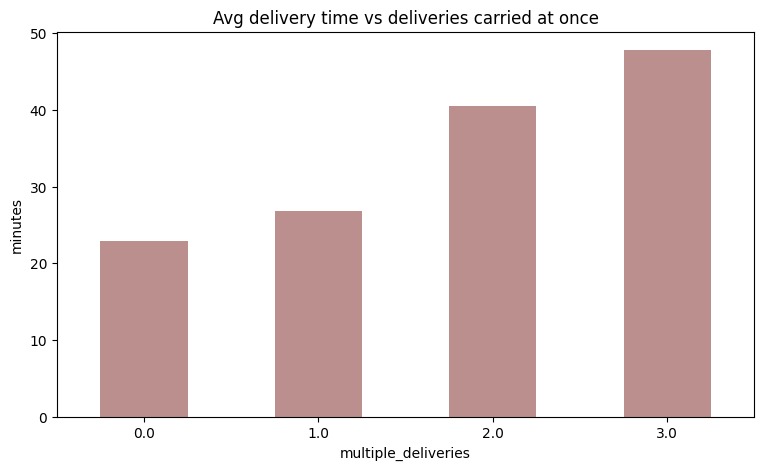

In [74]:
plt.figure(figsize=(9, 5))
df.groupby('multiple_deliveries')['time_taken'].mean().plot(
    kind='bar', title='Avg delivery time vs deliveries carried at once', color='rosybrown')
plt.ylabel('minutes')
plt.xticks(rotation=0)
plt.show()

## 15.Festival days

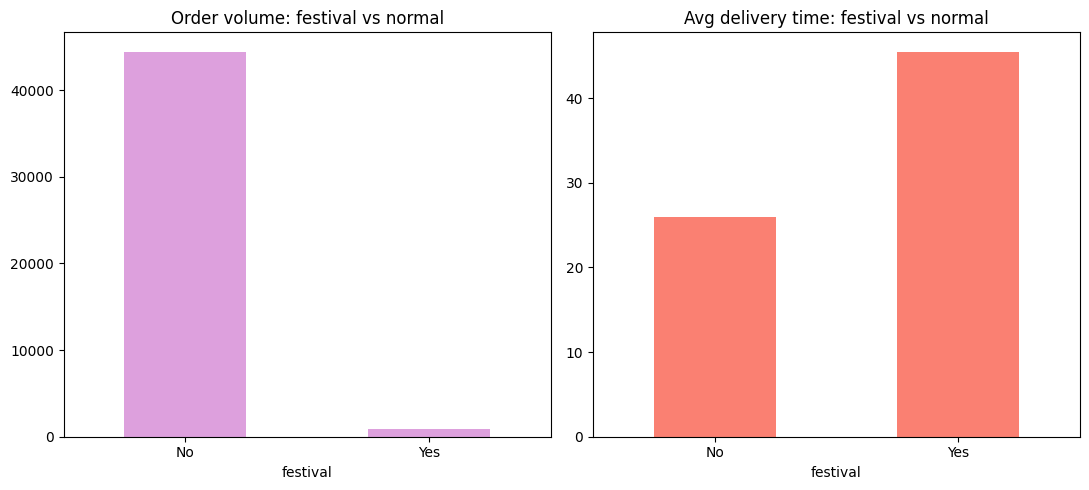

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

df['festival'].value_counts().plot(kind='bar', ax=axes[0], color='plum', title='Order volume: festival vs normal', rot=0)

df.groupby('festival')['time_taken'].mean().plot(kind='bar', ax=axes[1], color='salmon', title='Avg delivery time: festival vs normal', rot=0)

plt.tight_layout()
plt.show()

In [79]:
pd.crosstab(df['festival'], df['traffic'], normalize='index').mul(100).round(1)

traffic,High,Jam,Low,Medium
festival,,,,
No,9.9,30.7,34.9,24.6
Yes,7.8,71.7,5.7,14.8


Traffic mix looks pretty similar on both festival and normal days, so the slowdown probably isn't just a traffic thing, might be something else this dataset doesn't capture (like restaurants being slower to prep food).

<Figure size 1200x500 with 0 Axes>

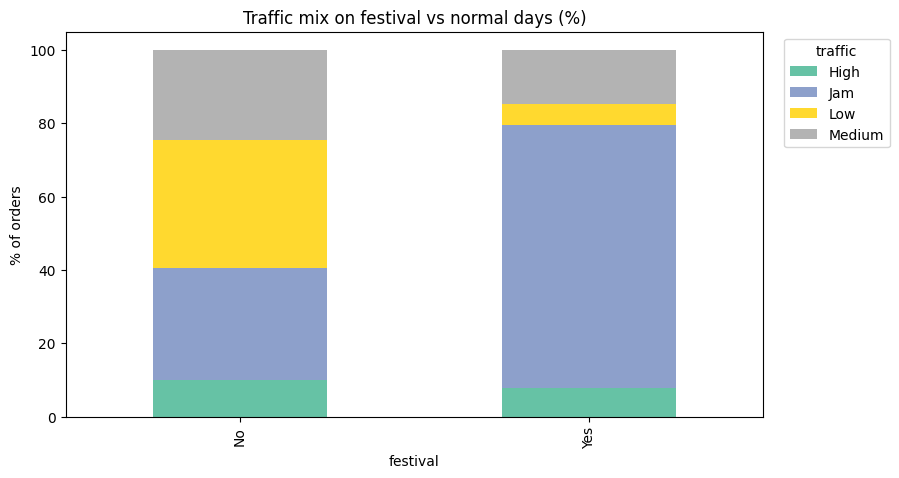

traffic,High,Jam,Low,Medium
festival,,,,
No,9.9,30.7,34.9,24.6
Yes,7.8,71.7,5.7,14.8


In [86]:
# checking if festival days just have worse traffic overall, which
# would explain the slowdown better than the festival itself
plt.figure(figsize=(12, 5))
festival_traffic_pct = pd.crosstab(df['festival'], df['traffic'], normalize='index') * 100

festival_traffic_pct.plot.bar(
    stacked=True, 
    figsize=(9, 5), 
    colormap='Set2', 
    title='Traffic mix on festival vs normal days (%)', 
    xlabel='festival', 
    ylabel='% of orders'
)
plt.legend(title='traffic', bbox_to_anchor=(1.02, 1))
plt.show()

festival_traffic_pct.round(1)

## 16.Correlation between numeric columns

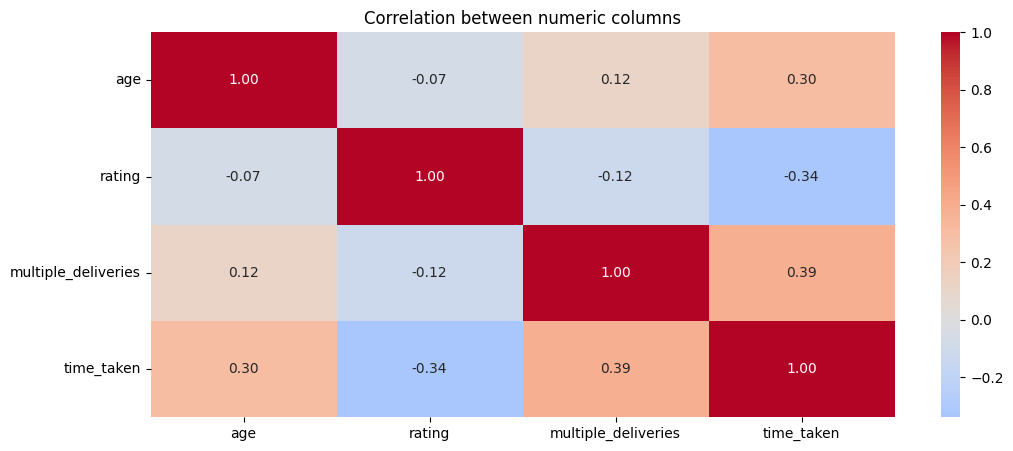

In [87]:
plt.figure(figsize=(12, 5))
corr = df[['age', 'rating', 'multiple_deliveries', 'time_taken']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between numeric columns')
plt.show()

Nothing numeric is strongly related to delivery time on its own, so weather/traffic matter a lot more than any single number about the driver.

## 17.Top and bottom drivers

Only counting drivers with 5+ deliveries so one lucky or unlucky order doesn't skew the list.

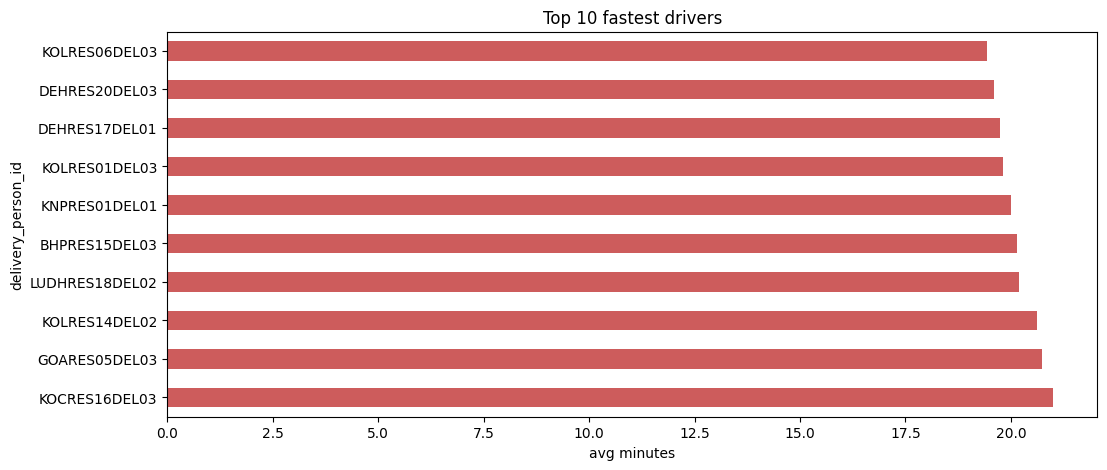

In [88]:
plt.figure(figsize=(12, 5))
driver_avg = df.groupby('delivery_person_id')['time_taken'].agg(['mean', 'count'])
driver_avg = driver_avg[driver_avg['count'] >= 5]

driver_avg['mean'].sort_values().head(10).plot(kind='barh', title='Top 10 fastest drivers',color='indianred')
plt.xlabel('avg minutes')
plt.gca().invert_yaxis()
plt.show()

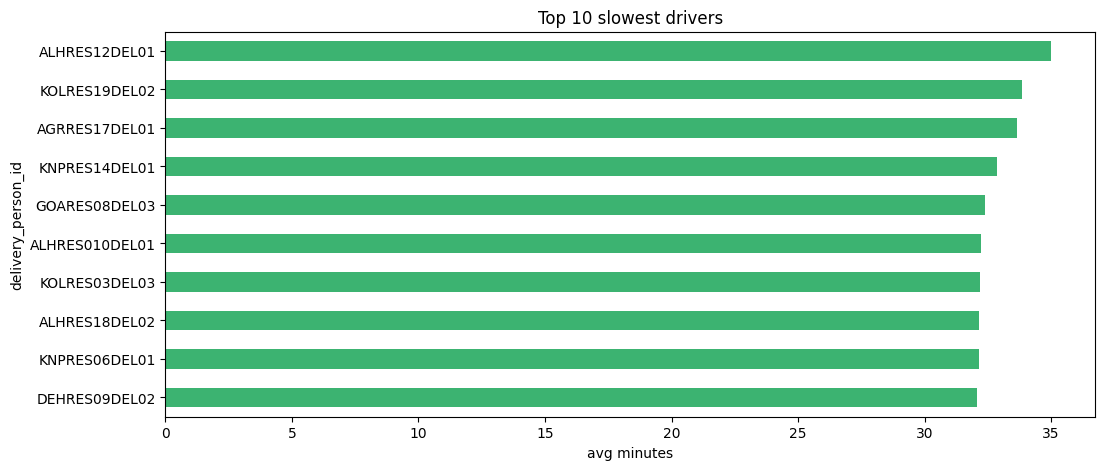

In [89]:
plt.figure(figsize=(12, 5))
driver_avg['mean'].sort_values(ascending=False).head(10).plot(kind='barh', title='Top 10 slowest drivers', color='mediumseagreen')
plt.xlabel('avg minutes')
plt.gca().invert_yaxis()
plt.show()

## Wrapping up

- traffic and weather matter way more than anything about the driver
- weather + traffic combos are worse together than either one alone
- driver age doesn't seem to affect speed much
- rating and speed aren't the same thing
- festival days are slower but it's not just because of extra traffic
